# 제출 2. 모델 확장 및 비교

**데이터:** `mock_data_3.csv` (20,000건)  
**모델:** Logistic Regression · Random Forest · CatBoost  
**목표:** 구독 해지 후보(클래스 0) 분류 성능 비교 분석

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
)
from catboost import CatBoostClassifier

---
## 1. 데이터 변경 및 피처 엔지니어링
### 1-1. 데이터 로드 및 기본 탐색

In [2]:
raw = pd.read_csv("mock_data_3.csv").copy()
raw["billing_cycle"] = raw["billing_cycle"].astype(int)

print(f"데이터 크기: {raw.shape[0]:,}건 × {raw.shape[1]}개 변수")
print()
print("── 변수 정보 ──")
print(raw.dtypes.to_string())
print()
print("── 결측치 ──")
print(raw.isnull().sum().to_string())

데이터 크기: 20,000건 × 13개 변수

── 변수 정보 ──
subscription_type             str
monthly_cost                int64
use_frequency                 str
last_use_recency              str
perceived_necessity         int64
cost_burden                 int64
would_rebuy                 int64
replacement_available       int64
billing_cycle               int64
remaining_months          float64
discount_amount             int64
effective_monthly_cost      int64
target                      int64

── 결측치 ──
subscription_type         0
monthly_cost              0
use_frequency             0
last_use_recency          0
perceived_necessity       0
cost_burden               0
would_rebuy               0
replacement_available     0
billing_cycle             0
remaining_months          0
discount_amount           0
effective_monthly_cost    0
target                    0


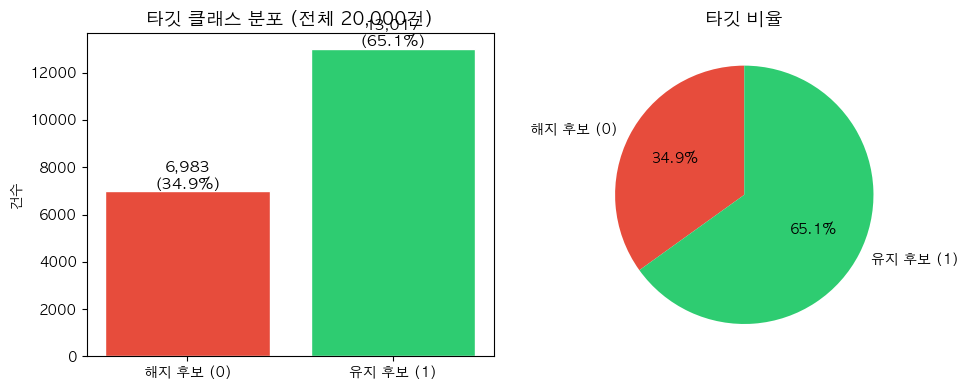

target=0 (해지 후보): 6,983건  (34.9%)
target=1 (유지 후보): 13,017건  (65.1%)


In [3]:
# 타깃 분포 시각화
target_counts = raw["target"].value_counts().sort_index()
labels = ["해지 후보 (0)", "유지 후보 (1)"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, target_counts.values, color=["#E74C3C", "#2ECC71"], edgecolor="white")
axes[0].set_title("타깃 클래스 분포 (전체 20,000건)", fontsize=13)
axes[0].set_ylabel("건수")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v/len(raw)*100:.1f}%)", ha="center", fontsize=11)

axes[1].pie(
    target_counts.values,
    labels=labels,
    autopct="%1.1f%%",
    colors=["#E74C3C", "#2ECC71"],
    startangle=90,
)
axes[1].set_title("타깃 비율", fontsize=13)

plt.tight_layout()
plt.show()

print(f"target=0 (해지 후보): {target_counts[0]:,}건  ({target_counts[0]/len(raw)*100:.1f}%)")
print(f"target=1 (유지 후보): {target_counts[1]:,}건  ({target_counts[1]/len(raw)*100:.1f}%)")

### 1-2. 연간 구독 처리 방안

#### 방안 1. 월환산 비용 정규화
`mock_data_3.csv`는 `monthly_cost`가 이미 월 단위 금액으로 제공되며,  
`effective_monthly_cost`(= `monthly_cost − discount_amount`)도 사전 산출되어 있다.  
따라서 `annual_cost / 12` 변환은 생략하고 `effective_monthly_cost`를 기준값으로 사용한다.

#### 방안 2. 잔여 기간 3개월 초과 시 처리 보류
연간 구독(`billing_cycle == 1`) 중 잔여 구독 기간이 3개월을 초과하는 건은  
즉시 해지 결정이 실용적이지 않으므로 예측 대상(`df_deferred`)에서 제외한다.  
이후 모든 모델 학습·평가는 `df_active` 기준으로 수행한다.

In [4]:
DEFERRAL_THRESHOLD_MONTHS = 3

raw["is_deferred"] = (
    (raw["billing_cycle"] == 1) & (raw["remaining_months"] > DEFERRAL_THRESHOLD_MONTHS)
).astype(int)

df_deferred = raw[raw["is_deferred"] == 1].copy().reset_index(drop=True)
df_active   = raw[raw["is_deferred"] == 0].copy().reset_index(drop=True)

print(f"전체:                    {len(raw):,}건")
print(f"예측 대상 (df_active):   {len(df_active):,}건")
print(f"처리 보류 (df_deferred): {len(df_deferred):,}건")
print()

active_counts = df_active["target"].value_counts().sort_index()
print("df_active 타깃 분포:")
print(f"  target=0 (해지 후보): {active_counts[0]:,}건  ({active_counts[0]/len(df_active)*100:.1f}%)")
print(f"  target=1 (유지 후보): {active_counts[1]:,}건  ({active_counts[1]/len(df_active)*100:.1f}%)")

# 이후 모든 작업은 df_active 기준
df = df_active.copy()

전체:                    20,000건
예측 대상 (df_active):   15,528건
처리 보류 (df_deferred): 4,472건

df_active 타깃 분포:
  target=0 (해지 후보): 5,669건  (36.5%)
  target=1 (유지 후보): 9,859건  (63.5%)


### 1-3. 피처 엔지니어링

#### 순서형 인코딩
| 변수 | 인코딩 |
|---|---|
| `use_frequency` | rare→1, monthly→2, weekly→3, frequent→4 |
| `last_use_recency` | \>30d→1, 7-30d→2, 1-7d→3, \<1d→4 |

#### 파생 변수 목록 (13개)
| 파생 변수명 | 설계 의도 |
|---|---|
| `effective_monthly_cost` | 할인 차감 후 실질 월 결제액 |
| `is_zero_cost` | 실질 결제 0원 여부 플래그 |
| `value_gap` | 사용 가치 − 비용 부담 (순수 유지 가치) |
| `rebuy_satisfaction_gap` | 실질 비용 대비 만족도 격차 |
| `cost_to_necessity_ratio` | 필요도 반영 실질 비용 절댓값 |
| `log_monthly_cost` | 오른쪽 꼬리 완화 |
| `monthly_cost_z` | Z-score 표준화 |
| `cost_burden_x_replacement` | 비용 부담 × 대체재 상호작용 |
| `necessity_x_recency` | 필요도 × 최근성 상호작용 |
| `frequency_x_rebuy` | 이용빈도 × 재구독의향 상호작용 |
| `is_high_cost` | 75th percentile 초과 고비용 플래그 |
| `has_churn_signal` | 저빈도+저최근성+고부담 복합 이탈 신호 |
| `is_deferred` | 연간 구독 잔여 3개월 초과 보류 플래그 |

In [5]:
# ── 순서형 인코딩 ─────────────────────────────────────────────────────────
use_frequency_map    = {"rare": 1, "monthly": 2, "weekly": 3, "frequent": 4}
last_use_recency_map = {">30d": 1, "7-30d": 2, "1-7d": 3, "<1d": 4}

df["use_frequency_score"]    = df["use_frequency"].map(use_frequency_map)
df["last_use_recency_score"] = df["last_use_recency"].map(last_use_recency_map)

# ── 실질 결제 금액 (이미 CSV에 포함되어 있으나, 명시적으로 재산출)
df["effective_monthly_cost"] = (df["monthly_cost"] - df["discount_amount"]).clip(lower=0)
df["is_zero_cost"]           = (df["effective_monthly_cost"] == 0).astype(int)

# ── 비용 기반 파생 변수 ───────────────────────────────────────────────────
df["log_monthly_cost"]        = np.log1p(df["effective_monthly_cost"])
df["monthly_cost_z"]          = (
    (df["effective_monthly_cost"] - df["effective_monthly_cost"].mean())
    / df["effective_monthly_cost"].std(ddof=0)
)
df["rebuy_satisfaction_gap"]  = df["effective_monthly_cost"] - df["perceived_necessity"]
df["cost_to_necessity_ratio"] = df["effective_monthly_cost"] * (df["perceived_necessity"] + 1e-6)

# ── 활용 기반 파생 변수 ───────────────────────────────────────────────────
df["value_gap"] = (
    df["use_frequency_score"]
    + df["last_use_recency_score"]
    + df["perceived_necessity"]
    - df["cost_burden"]
)
df["cost_burden_x_replacement"] = df["cost_burden"] * df["replacement_available"]
df["necessity_x_recency"]       = df["perceived_necessity"] * df["last_use_recency_score"]
df["frequency_x_rebuy"]         = df["use_frequency_score"] * df["would_rebuy"]

# ── 이진 플래그 ───────────────────────────────────────────────────────────
high_cost_threshold = df["effective_monthly_cost"].quantile(0.75)
df["is_high_cost"]   = (df["effective_monthly_cost"] > high_cost_threshold).astype(int)

df["has_churn_signal"] = (
    (df["use_frequency_score"]    <= 2)
    & (df["last_use_recency_score"] <= 2)
    & (df["cost_burden"]            >= 4)
).astype(int)

# ── 파생 변수 확인 ────────────────────────────────────────────────────────
derived_cols = [
    "effective_monthly_cost", "is_zero_cost",
    "use_frequency_score", "last_use_recency_score",
    "value_gap", "rebuy_satisfaction_gap", "cost_to_necessity_ratio",
    "log_monthly_cost", "monthly_cost_z",
    "cost_burden_x_replacement", "necessity_x_recency", "frequency_x_rebuy",
    "is_high_cost", "has_churn_signal",
]
print(f"파생 변수 수: {len(derived_cols)}개")
display(df[derived_cols].describe().T.round(4))

파생 변수 수: 14개


,count,mean,std,min,25%,50%,75%,max
effective_monthly_cost,15528.0,15306.5301,11003.3146,1500.0000,8200.0000,11800.0000,18500.0000,88700.0000
is_zero_cost,15528.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
use_frequency_score,15528.0,2.6166,1.0747,1.0000,2.0000,3.0000,4.0000,4.0000
last_use_recency_score,15528.0,2.6884,1.0926,1.0000,2.0000,3.0000,4.0000,4.0000
value_gap,15528.0,6.0669,3.2390,-2.0000,4.0000,6.0000,9.0000,12.0000
rebuy_satisfaction_gap,15528.0,15303.5493,11003.3357,1496.0000,8195.0000,11797.0000,18498.0000,88698.0000
cost_to_necessity_ratio,15528.0,45395.0308,40156.6731,1500.0015,19500.0065,34000.0085,56100.0187,415000.0830
log_monthly_cost,15528.0,9.4216,0.6509,7.3139,9.0120,9.3759,9.8256,11.3930
monthly_cost_z,15528.0,-0.0000,1.0000,-1.2548,-0.6459,-0.3187,0.2902,6.6703
cost_burden_x_replacement,15528.0,1.1078,1.2415,0.0000,0.0000,1.0000,2.0000,5.0000


---
## 2. 모델 파이프라인 구성

| 피처 그룹 | 전처리 | 해당 변수 |
|---|---|---|
| 명목형 (nominal) | OneHotEncoder | `subscription_type`, `use_frequency`, `last_use_recency` |
| 순서형·연속형 (ordinal/continuous) | StandardScaler | `perceived_necessity`, `value_gap`, `log_monthly_cost` 등 |
| 이진형 (binary) | passthrough | `replacement_available`, `is_high_cost`, `has_churn_signal` 등 |

In [6]:
TARGET_COL = "target"

nominal_cols = ["subscription_type", "use_frequency", "last_use_recency"]
ordinal_cols = ["perceived_necessity", "cost_burden", "would_rebuy"]
continuous_cols = [
    "effective_monthly_cost",
    "log_monthly_cost",
    "monthly_cost_z",
    "value_gap",
    "rebuy_satisfaction_gap",
    "cost_to_necessity_ratio",
    "cost_burden_x_replacement",
    "necessity_x_recency",
    "frequency_x_rebuy",
    "remaining_months",
    "discount_amount",
]
binary_cols = [
    "replacement_available",
    "billing_cycle",
    "is_high_cost",
    "has_churn_signal",
    "is_zero_cost",
]

nominal_cols    = [c for c in nominal_cols    if c in df.columns]
ordinal_cols    = [c for c in ordinal_cols    if c in df.columns]
continuous_cols = [c for c in continuous_cols if c in df.columns]
binary_cols     = [c for c in binary_cols     if c in df.columns]

all_feature_cols = nominal_cols + ordinal_cols + continuous_cols + binary_cols
X = df[all_feature_cols]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터: {len(X_train):,}건  |  테스트 데이터: {len(X_test):,}건")
print(f"테스트 셋 클래스 0: {(y_test==0).sum():,}건  |  클래스 1: {(y_test==1).sum():,}건")
print(f"총 피처 수: {len(all_feature_cols)}개")

# 전처리기 (LR용 - 스케일링 포함)
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("nominal",  OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("ord_cont", StandardScaler(), ordinal_cols + continuous_cols),
        ("binary",   "passthrough", binary_cols),
    ],
    remainder="drop",
)

# 전처리기 (RF용 - 스케일링 불필요)
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("nominal",  OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("num_bin",  "passthrough", ordinal_cols + continuous_cols + binary_cols),
    ],
    remainder="drop",
)

학습 데이터: 12,422건  |  테스트 데이터: 3,106건
테스트 셋 클래스 0: 1,134건  |  클래스 1: 1,972건
총 피처 수: 22개


---
### 2-1. Logistic Regression (기준 모델)

- 선형 결정 경계 기반 기준선(baseline) 제공
- `class_weight="balanced"` 로 클래스 불균형 보정
- **한계:** 변수 간 비선형 상호작용 포착 불가

In [7]:
lr_model = LogisticRegression(random_state=42, max_iter=3000, class_weight="balanced")
clf_lr   = Pipeline([("preprocess", preprocessor_lr), ("model", lr_model)])
clf_lr.fit(X_train, y_train)

y_pred_lr  = clf_lr.predict(X_test)
y_proba_lr = clf_lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}")
print("-" * 50)
print(f"[target=0] Precision: {precision_score(y_test, y_pred_lr, pos_label=0):.4f} "
      f"| Recall: {recall_score(y_test, y_pred_lr, pos_label=0):.4f} "
      f"| F1: {f1_score(y_test, y_pred_lr, pos_label=0):.4f}")
print(f"[target=1] Precision: {precision_score(y_test, y_pred_lr, pos_label=1):.4f} "
      f"| Recall: {recall_score(y_test, y_pred_lr, pos_label=1):.4f} "
      f"| F1: {f1_score(y_test, y_pred_lr, pos_label=1):.4f}")
print("-" * 50)
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))
print("-" * 50)
print(classification_report(y_test, y_pred_lr, digits=4))

=== Logistic Regression ===
Accuracy : 0.7077
ROC-AUC  : 0.7833
--------------------------------------------------
[target=0] Precision: 0.5809 | Recall: 0.7152 | F1: 0.6411
[target=1] Precision: 0.8111 | Recall: 0.7033 | F1: 0.7534
--------------------------------------------------
Confusion Matrix
[[ 811  323]
 [ 585 1387]]
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.5809    0.7152    0.6411      1134
           1     0.8111    0.7033    0.7534      1972

    accuracy                         0.7077      3106
   macro avg     0.6960    0.7093    0.6973      3106
weighted avg     0.7271    0.7077    0.7124      3106



---
### 2-2. Random Forest (비선형 앙상블)

- 다수의 Decision Tree 병렬 학습 (Bagging)
- `class_weight="balanced_subsample"` 로 소수 클래스 탐지 강화
- **선택 이유:** 복잡한 조합 패턴(rare + >30d + cost_burden≥4) 포착 가능

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=8,
    min_samples_leaf=4,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
clf_rf = Pipeline([("preprocess", preprocessor_rf), ("model", rf_model)])
clf_rf.fit(X_train, y_train)

y_pred_rf  = clf_rf.predict(X_test)
y_proba_rf = clf_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_rf):.4f}")
print("-" * 50)
print(f"[target=0] Precision: {precision_score(y_test, y_pred_rf, pos_label=0):.4f} "
      f"| Recall: {recall_score(y_test, y_pred_rf, pos_label=0):.4f} "
      f"| F1: {f1_score(y_test, y_pred_rf, pos_label=0):.4f}")
print(f"[target=1] Precision: {precision_score(y_test, y_pred_rf, pos_label=1):.4f} "
      f"| Recall: {recall_score(y_test, y_pred_rf, pos_label=1):.4f} "
      f"| F1: {f1_score(y_test, y_pred_rf, pos_label=1):.4f}")
print("-" * 50)
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))
print("-" * 50)
print(classification_report(y_test, y_pred_rf, digits=4))

=== Random Forest ===
Accuracy : 0.7218
ROC-AUC  : 0.7769
--------------------------------------------------
[target=0] Precision: 0.6158 | Recall: 0.6332 | F1: 0.6243
[target=1] Precision: 0.7856 | Recall: 0.7728 | F1: 0.7791
--------------------------------------------------
Confusion Matrix
[[ 718  416]
 [ 448 1524]]
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.6158    0.6332    0.6243      1134
           1     0.7856    0.7728    0.7791      1972

    accuracy                         0.7218      3106
   macro avg     0.7007    0.7030    0.7017      3106
weighted avg     0.7236    0.7218    0.7226      3106



---
### 2-3. CatBoost (범주형 특화 그래디언트 부스팅)

- Ordered Boosting 방식으로 과적합 억제
- `subscription_type`, `use_frequency`, `last_use_recency` 를 `cat_features`로 직접 지정
- **선택 이유:** 범주형 변수 다수 포함 데이터에서 최적 성능 기대

In [9]:
cat_cols = ["subscription_type", "use_frequency", "last_use_recency"]
num_cols = [
    "effective_monthly_cost", "perceived_necessity", "cost_burden", "would_rebuy",
    "replacement_available", "billing_cycle", "remaining_months", "discount_amount",
    "log_monthly_cost", "monthly_cost_z", "value_gap", "rebuy_satisfaction_gap",
    "cost_to_necessity_ratio", "cost_burden_x_replacement", "necessity_x_recency",
    "frequency_x_rebuy", "is_high_cost", "has_churn_signal", "is_zero_cost",
]
cat_cols = [c for c in cat_cols if c in df.columns]
num_cols = [c for c in num_cols if c in df.columns]

X_cat = df[cat_cols + num_cols].copy()
y_cat = df[TARGET_COL].astype(int)
for c in cat_cols:
    X_cat[c] = X_cat[c].astype(str)

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

cat_feature_idx = [X_train_cat.columns.get_loc(c) for c in cat_cols]
neg, pos = np.bincount(y_train_cat)
class_weights = [1.0, neg / pos]

cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    random_seed=42,
    class_weights=class_weights,
    verbose=200,
)
cat_model.fit(
    X_train_cat, y_train_cat,
    cat_features=cat_feature_idx,
    eval_set=(X_test_cat, y_test_cat),
    use_best_model=True,
)

y_pred_cat  = cat_model.predict(X_test_cat).astype(int).ravel()
y_proba_cat = cat_model.predict_proba(X_test_cat)[:, 1]

print("=== CatBoost ===")
print(f"Accuracy : {accuracy_score(y_test_cat, y_pred_cat):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_cat, y_proba_cat):.4f}")
print("-" * 50)
print(f"[target=0] Precision: {precision_score(y_test_cat, y_pred_cat, pos_label=0):.4f} "
      f"| Recall: {recall_score(y_test_cat, y_pred_cat, pos_label=0):.4f} "
      f"| F1: {f1_score(y_test_cat, y_pred_cat, pos_label=0):.4f}")
print(f"[target=1] Precision: {precision_score(y_test_cat, y_pred_cat, pos_label=1):.4f} "
      f"| Recall: {recall_score(y_test_cat, y_pred_cat, pos_label=1):.4f} "
      f"| F1: {f1_score(y_test_cat, y_pred_cat, pos_label=1):.4f}")
print("-" * 50)
print("Confusion Matrix")
print(confusion_matrix(y_test_cat, y_pred_cat))
print("-" * 50)
print(classification_report(y_test_cat, y_pred_cat, digits=4))

0:	test: 0.7641440	best: 0.7641440 (0)	total: 77.7ms	remaining: 1m 33s
200:	test: 0.7828032	best: 0.7838516 (57)	total: 2.98s	remaining: 14.8s
400:	test: 0.7813127	best: 0.7838516 (57)	total: 5.23s	remaining: 10.4s
600:	test: 0.7794650	best: 0.7838516 (57)	total: 6.82s	remaining: 6.79s
800:	test: 0.7768660	best: 0.7838516 (57)	total: 8.76s	remaining: 4.36s
1000:	test: 0.7752271	best: 0.7838516 (57)	total: 10.5s	remaining: 2.09s
1199:	test: 0.7735672	best: 0.7838516 (57)	total: 12.4s	remaining: 0us

bestTest = 0.7838515674
bestIteration = 57

Shrink model to first 58 iterations.
=== CatBoost ===
Accuracy : 0.7057
ROC-AUC  : 0.7839
--------------------------------------------------
[target=0] Precision: 0.5777 | Recall: 0.7213 | F1: 0.6416
[target=1] Precision: 0.8130 | Recall: 0.6968 | F1: 0.7504
--------------------------------------------------
Confusion Matrix
[[ 818  316]
 [ 598 1374]]
--------------------------------------------------
              precision    recall  f1-score   s

---
## 3. 모델 성능 비교
### 3-1. 성능 지표 비교표 및 시각화

,Accuracy,ROC-AUC,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1)
Logistic Regression,0.7077,0.7833,0.5809,0.7152,0.6411,0.8111,0.7033,0.7534
Random Forest,0.7218,0.7769,0.6158,0.6332,0.6243,0.7856,0.7728,0.7791
CatBoost,0.7057,0.7839,0.5777,0.7213,0.6416,0.8130,0.6968,0.7504


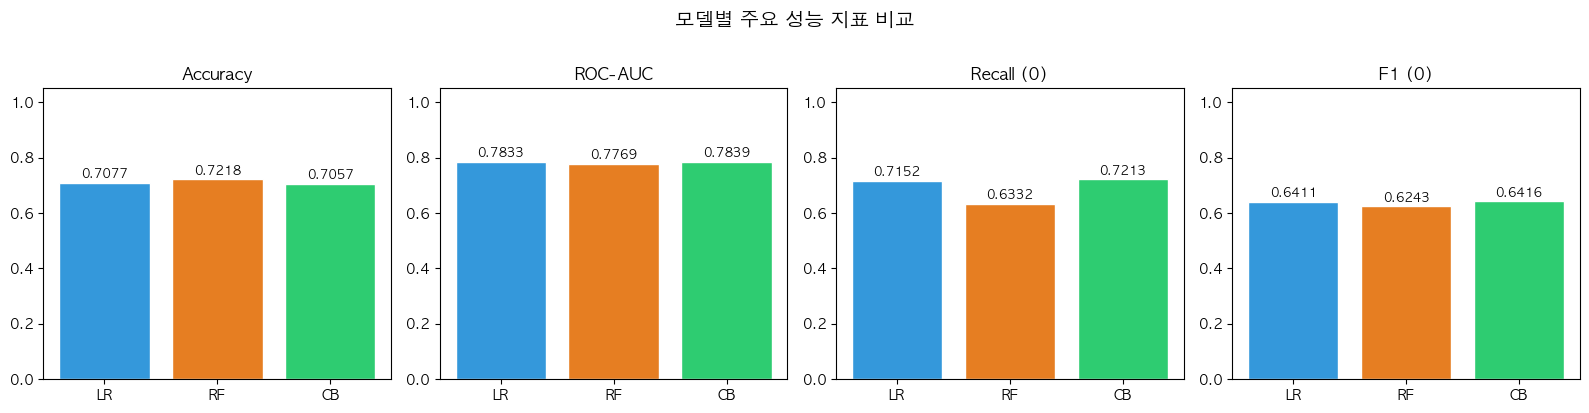

In [10]:
results = {}

for name, y_true, y_pred, y_proba in [
    ("Logistic Regression", y_test,     y_pred_lr,  y_proba_lr),
    ("Random Forest",       y_test,     y_pred_rf,  y_proba_rf),
    ("CatBoost",            y_test_cat, y_pred_cat, y_proba_cat),
]:
    results[name] = {
        "Accuracy":      round(accuracy_score(y_true, y_pred), 4),
        "ROC-AUC":       round(roc_auc_score(y_true, y_proba), 4),
        "Precision (0)": round(precision_score(y_true, y_pred, pos_label=0), 4),
        "Recall (0)":    round(recall_score(y_true, y_pred, pos_label=0), 4),
        "F1 (0)":        round(f1_score(y_true, y_pred, pos_label=0), 4),
        "Precision (1)": round(precision_score(y_true, y_pred, pos_label=1), 4),
        "Recall (1)":    round(recall_score(y_true, y_pred, pos_label=1), 4),
        "F1 (1)":        round(f1_score(y_true, y_pred, pos_label=1), 4),
    }

summary_df = pd.DataFrame(results).T
display(summary_df.style.highlight_max(axis=0, color="#d4edda").format("{:.4f}"))

# 주요 지표 막대 그래프
metrics_to_plot = ["Accuracy", "ROC-AUC", "Recall (0)", "F1 (0)"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ["#3498DB", "#E67E22", "#2ECC71"]
model_names = list(results.keys())

for ax, metric in zip(axes, metrics_to_plot):
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor="white")
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(["LR", "RF", "CB"], fontsize=10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("모델별 주요 성능 지표 비교", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3-2. 혼동 행렬 비교

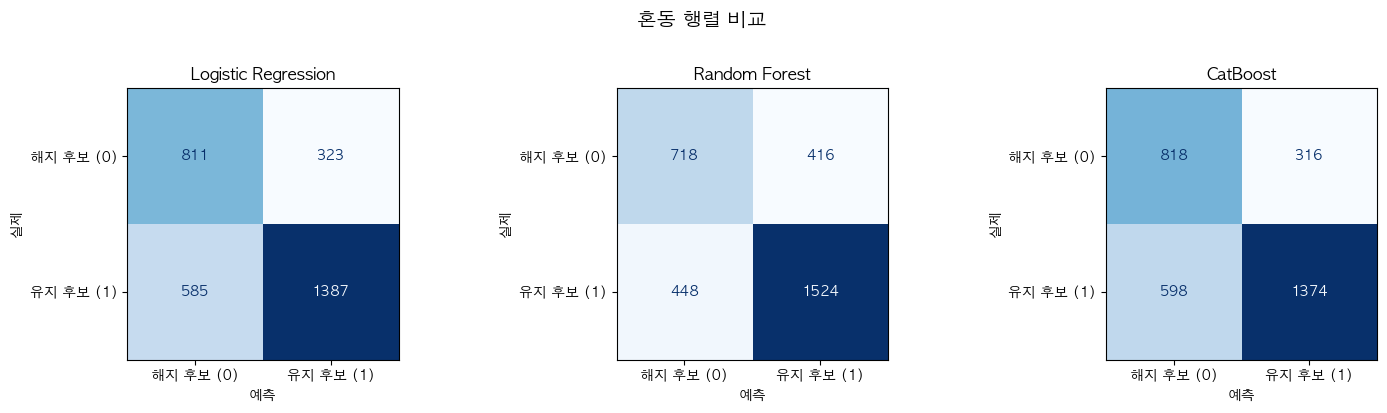

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm_data = [
    ("Logistic Regression", y_test,     y_pred_lr),
    ("Random Forest",       y_test,     y_pred_rf),
    ("CatBoost",            y_test_cat, y_pred_cat),
]

for ax, (name, y_true, y_pred) in zip(axes, cm_data):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["해지 후보 (0)", "유지 후보 (1)"],
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("예측")
    ax.set_ylabel("실제")

plt.suptitle("혼동 행렬 비교", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. 피처 중요도 분석

Random Forest의 `feature_importances_`와 CatBoost의 `get_feature_importance()`를 비교하여  
어떤 변수가 분류에 가장 큰 영향을 미치는지 분석한다.

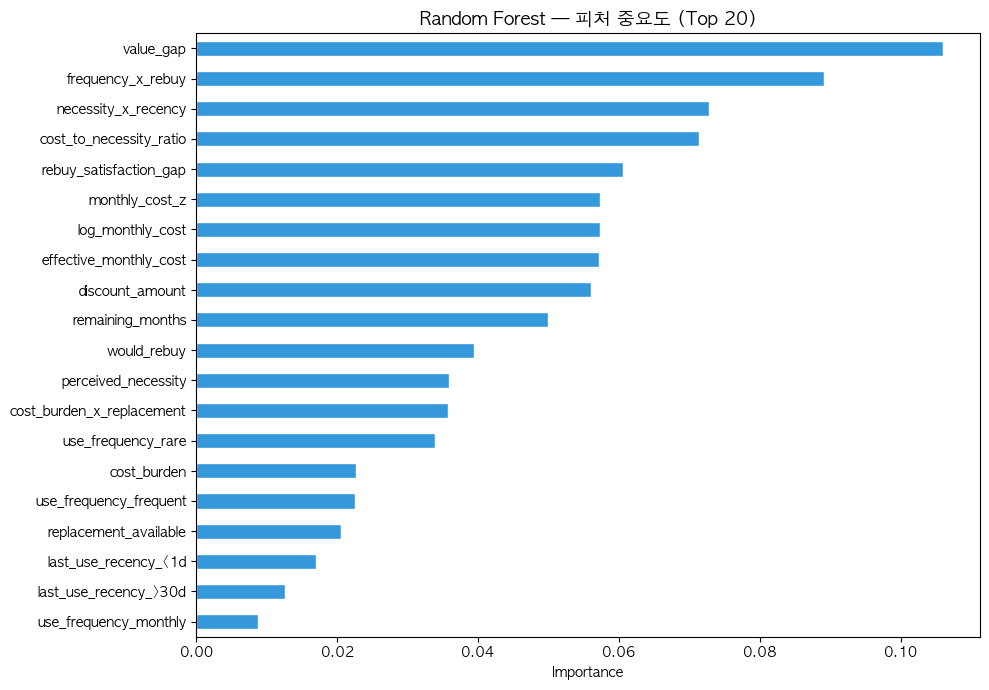

Top 10 피처 (Random Forest):
value_gap                  0.105953
frequency_x_rebuy          0.089174
necessity_x_recency        0.072786
cost_to_necessity_ratio    0.071349
rebuy_satisfaction_gap     0.060561
monthly_cost_z             0.057325
log_monthly_cost           0.057285
effective_monthly_cost     0.057216
discount_amount            0.055966
remaining_months           0.049945


In [12]:
# ── Random Forest 피처 중요도 ─────────────────────────────────────────────
ohe_feature_names = (
    clf_rf.named_steps["preprocess"]
    .named_transformers_["nominal"]
    .get_feature_names_out(nominal_cols)
    .tolist()
)
rf_feature_names = ohe_feature_names + ordinal_cols + continuous_cols + binary_cols
rf_importances   = clf_rf.named_steps["model"].feature_importances_

fi_rf = (
    pd.Series(rf_importances, index=rf_feature_names)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
fi_rf[::-1].plot(kind="barh", ax=ax, color="#3498DB", edgecolor="white")
ax.set_title("Random Forest — 피처 중요도 (Top 20)", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 피처 (Random Forest):")
print(fi_rf.head(10).to_string())

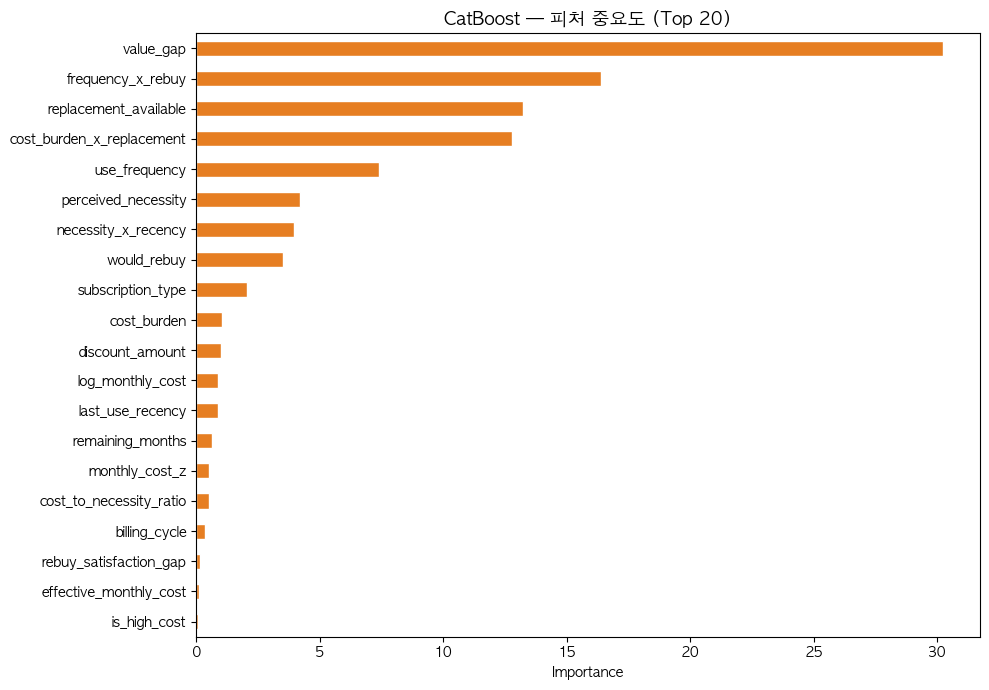

Top 10 피처 (CatBoost):
value_gap                    30.222040
frequency_x_rebuy            16.366218
replacement_available        13.216500
cost_burden_x_replacement    12.801236
use_frequency                 7.412958
perceived_necessity           4.217127
necessity_x_recency           3.955097
would_rebuy                   3.502852
subscription_type             2.043716
cost_burden                   1.023401


In [13]:
# ── CatBoost 피처 중요도 ──────────────────────────────────────────────────
cat_feature_names = cat_cols + num_cols
cat_importances   = cat_model.get_feature_importance()

fi_cat = (
    pd.Series(cat_importances, index=cat_feature_names)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
fi_cat[::-1].plot(kind="barh", ax=ax, color="#E67E22", edgecolor="white")
ax.set_title("CatBoost — 피처 중요도 (Top 20)", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 피처 (CatBoost):")
print(fi_cat.head(10).to_string())

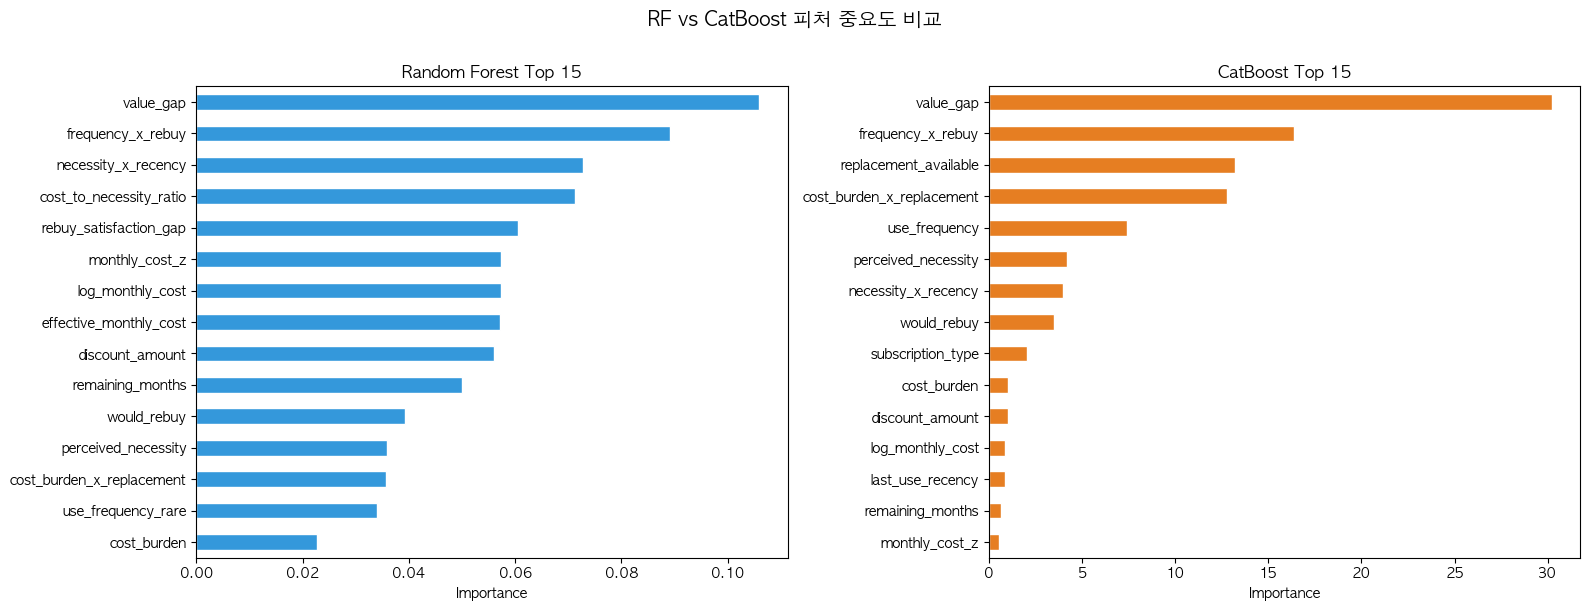

공통 Top 15 피처 (11개): ['cost_burden', 'cost_burden_x_replacement', 'discount_amount', 'frequency_x_rebuy', 'log_monthly_cost', 'monthly_cost_z', 'necessity_x_recency', 'perceived_necessity', 'remaining_months', 'value_gap', 'would_rebuy']


In [14]:
# ── RF vs CatBoost 피처 중요도 나란히 비교 ────────────────────────────────
top_n = 15
top_rf_feats  = set(fi_rf.head(top_n).index)
top_cat_feats = set(fi_cat.head(top_n).index)
common_feats  = top_rf_feats & top_cat_feats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fi_rf.head(top_n)[::-1].plot(kind="barh", ax=axes[0], color="#3498DB", edgecolor="white")
axes[0].set_title(f"Random Forest Top {top_n}", fontsize=12)
axes[0].set_xlabel("Importance")

fi_cat.head(top_n)[::-1].plot(kind="barh", ax=axes[1], color="#E67E22", edgecolor="white")
axes[1].set_title(f"CatBoost Top {top_n}", fontsize=12)
axes[1].set_xlabel("Importance")

plt.suptitle("RF vs CatBoost 피처 중요도 비교", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"공통 Top {top_n} 피처 ({len(common_feats)}개): {sorted(common_feats)}")

---
## 5. 모델별 결과 종합 정리

각 모델의 성능 지표, 혼동 행렬 수치, 강점/약점을 한눈에 비교한다.

In [15]:
# ── 모델별 결과 종합 정리 ──────────────────────────────────────────────────
model_meta = {
    "Logistic Regression": {
        "y_true": y_test, "y_pred": y_pred_lr, "y_proba": y_proba_lr,
        "color": "#3498DB",
        "pros":  "계수 분석으로 변수 방향성·크기 직접 해석 가능 (설명 가능성 최고)",
        "cons":  "비선형 상호작용 포착 불가 — ROC-AUC가 두 앙상블 대비 낮음",
        "note":  "기준선(Baseline) 모델. 선형 분리가 어려운 데이터에서 한계 명확.",
    },
    "Random Forest": {
        "y_true": y_test, "y_pred": y_pred_rf, "y_proba": y_proba_rf,
        "color": "#E67E22",
        "pros":  "Accuracy·F1(1) 최고 — 유지 후보를 잘못 해지로 분류하는 오류 최소",
        "cons":  "Recall(0)이 CatBoost 대비 낮아 해지 후보를 일부 놓침",
        "note":  "유지 후보 오분류 리스크 최소화 목적에 가장 적합.",
    },
    "CatBoost": {
        "y_true": y_test_cat, "y_pred": y_pred_cat, "y_proba": y_proba_cat,
        "color": "#2ECC71",
        "pros":  "Recall(0)·ROC-AUC 최고 — 실제 해지 후보 탐지 능력 최우수",
        "cons":  "Precision(0) 상대적으로 낮아 유지 후보를 해지로 과분류 경향",
        "note":  "해지 후보를 빠짐없이 탐지하는 핵심 목적에 가장 부합.",
    },
}

# ① 지표 테이블 출력
print("=" * 90)
print(f"{'모델':<22} {'Acc':>7} {'AUC':>7} {'P(0)':>7} {'R(0)':>7} {'F1(0)':>7} {'P(1)':>7} {'R(1)':>7} {'F1(1)':>7}")
print("=" * 90)
for name, m in model_meta.items():
    yt, yp, ypr = m["y_true"], m["y_pred"], m["y_proba"]
    print(
        f"{name:<22}"
        f" {accuracy_score(yt, yp):>7.4f}"
        f" {roc_auc_score(yt, ypr):>7.4f}"
        f" {precision_score(yt, yp, pos_label=0):>7.4f}"
        f" {recall_score(yt, yp, pos_label=0):>7.4f}"
        f" {f1_score(yt, yp, pos_label=0):>7.4f}"
        f" {precision_score(yt, yp, pos_label=1):>7.4f}"
        f" {recall_score(yt, yp, pos_label=1):>7.4f}"
        f" {f1_score(yt, yp, pos_label=1):>7.4f}"
    )
print("=" * 90)

# ② 혼동 행렬 수치 테이블 출력
print()
print(f"{'모델':<22} {'TN(0→0)':>10} {'FP(0→1)':>10} {'FN(1→0)':>10} {'TP(1→1)':>10}")
print("-" * 62)
for name, m in model_meta.items():
    tn, fp, fn, tp = confusion_matrix(m["y_true"], m["y_pred"]).ravel()
    print(f"{name:<22} {tn:>10,} {fp:>10,} {fn:>10,} {tp:>10,}")
print()
print("  TN: 해지 후보 → 해지 정답   FP: 해지 후보 → 유지 오분류")
print("  FN: 유지 후보 → 해지 오분류  TP: 유지 후보 → 유지 정답")

모델                         Acc     AUC    P(0)    R(0)   F1(0)    P(1)    R(1)   F1(1)
Logistic Regression     0.7077  0.7833  0.5809  0.7152  0.6411  0.8111  0.7033  0.7534
Random Forest           0.7218  0.7769  0.6158  0.6332  0.6243  0.7856  0.7728  0.7791
CatBoost                0.7057  0.7839  0.5777  0.7213  0.6416  0.8130  0.6968  0.7504

모델                        TN(0→0)    FP(0→1)    FN(1→0)    TP(1→1)
--------------------------------------------------------------
Logistic Regression           811        323        585      1,387
Random Forest                 718        416        448      1,524
CatBoost                      818        316        598      1,374

  TN: 해지 후보 → 해지 정답   FP: 해지 후보 → 유지 오분류
  FN: 유지 후보 → 해지 오분류  TP: 유지 후보 → 유지 정답


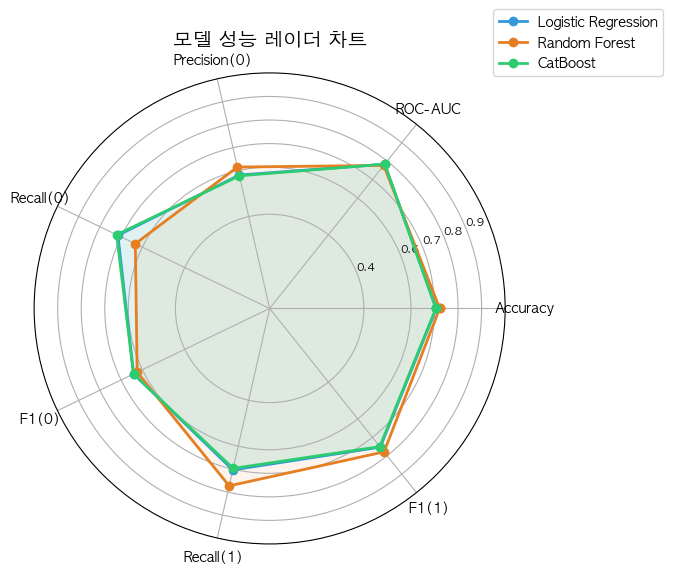

In [16]:
# ── 레이더 차트(Spider Chart)로 모델 특성 비교 ────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.path import Path

radar_metrics = ["Accuracy", "ROC-AUC", "Precision(0)", "Recall(0)", "F1(0)", "Recall(1)", "F1(1)"]
N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})

for name, m in model_meta.items():
    yt, yp, ypr = m["y_true"], m["y_pred"], m["y_proba"]
    values = [
        accuracy_score(yt, yp),
        roc_auc_score(yt, ypr),
        precision_score(yt, yp, pos_label=0),
        recall_score(yt, yp, pos_label=0),
        f1_score(yt, yp, pos_label=0),
        recall_score(yt, yp, pos_label=1),
        f1_score(yt, yp, pos_label=1),
    ]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=name, color=m["color"])
    ax.fill(angles, values, alpha=0.08, color=m["color"])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.4, 0.6, 0.7, 0.8, 0.9])
ax.set_yticklabels(["0.4", "0.6", "0.7", "0.8", "0.9"], size=8)
ax.set_title("모델 성능 레이더 차트", size=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

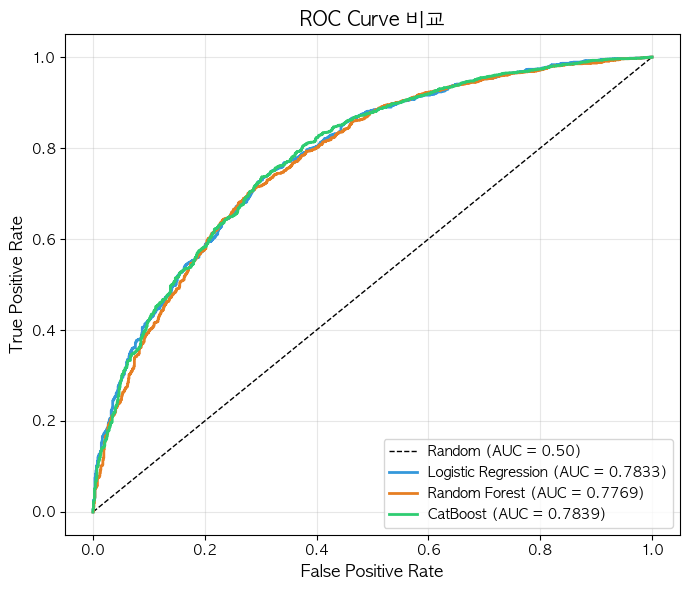

In [17]:
# ── ROC Curve 3개 모델 비교 ────────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.50)")

for name, m in model_meta.items():
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_proba"])
    auc_val = roc_auc_score(m["y_true"], m["y_proba"])
    ax.plot(fpr, tpr, linewidth=2, color=m["color"], label=f"{name} (AUC = {auc_val:.4f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve 비교", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ── 모델별 강점·약점·권장 상황 카드 출력 ─────────────────────────────────
sep = "─" * 68
for name, m in model_meta.items():
    yt, yp, ypr = m["y_true"], m["y_pred"], m["y_proba"]
    cm_vals = confusion_matrix(yt, yp).ravel()
    tn, fp, fn, tp = cm_vals
    print(sep)
    print(f"  {name}")
    print(sep)
    print(f"  Accuracy : {accuracy_score(yt, yp):.4f}   ROC-AUC : {roc_auc_score(yt, ypr):.4f}")
    print(f"  Precision(0): {precision_score(yt, yp, pos_label=0):.4f}  Recall(0): {recall_score(yt, yp, pos_label=0):.4f}  F1(0): {f1_score(yt, yp, pos_label=0):.4f}")
    print(f"  Precision(1): {precision_score(yt, yp, pos_label=1):.4f}  Recall(1): {recall_score(yt, yp, pos_label=1):.4f}  F1(1): {f1_score(yt, yp, pos_label=1):.4f}")
    print()
    print(f"  혼동 행렬  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print(f"  ├ 해지 후보 정탐 (TN): {tn:,}건  |  해지 후보 미탐 (FP): {fp:,}건")
    print(f"  └ 유지 후보 오탐 (FN): {fn:,}건  |  유지 후보 정탐 (TP): {tp:,}건")
    print()
    print(f"  [강점]  {m['pros']}")
    print(f"  [약점]  {m['cons']}")
    print(f"  [요약]  {m['note']}")
    print()

print(sep)
print("  최종 권장")
print(sep)
print("  · 해지 후보 빠짐없이 탐지 (Recall 중시)  →  CatBoost")
print("  · 전반적 분류 균형 (Accuracy/F1 중시)    →  Random Forest")
print("  · 계수 기반 해석 필요 (설명 가능성 중시)  →  Logistic Regression")
print(sep)

────────────────────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────────────────────
  Accuracy : 0.7077   ROC-AUC : 0.7833
  Precision(0): 0.5809  Recall(0): 0.7152  F1(0): 0.6411
  Precision(1): 0.8111  Recall(1): 0.7033  F1(1): 0.7534

  혼동 행렬  TN=811  FP=323  FN=585  TP=1,387
  ├ 해지 후보 정탐 (TN): 811건  |  해지 후보 미탐 (FP): 323건
  └ 유지 후보 오탐 (FN): 585건  |  유지 후보 정탐 (TP): 1,387건

  [강점]  계수 분석으로 변수 방향성·크기 직접 해석 가능 (설명 가능성 최고)
  [약점]  비선형 상호작용 포착 불가 — ROC-AUC가 두 앙상블 대비 낮음
  [요약]  기준선(Baseline) 모델. 선형 분리가 어려운 데이터에서 한계 명확.

────────────────────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────────────────────
  Accuracy : 0.7218   ROC-AUC : 0.7769
  Precision(0): 0.6158  Recall(0): 0.6332  F1(0): 0.6243
  Precision(1): 0.7856  Recall(1): 0.7728  F1(1): 0.7791

  혼동 행렬  TN=718  FP=416  FN=448  TP=1,524
  ├ 해지 후보 정탐 (TN): 718건  |  해지 후보 미탐 (FP): 416건
  └

---
## 6. Optuna 하이퍼파라미터 파인튜닝

Optuna의 베이지안 최적화(TPE 샘플러)로 세 모델을 각각 튜닝한다.  
**평가 지표:** `ROC-AUC` (5-Fold StratifiedKFold CV 평균)  
**탐색 횟수:** 각 모델 50 trials  

| 모델 | 주요 탐색 파라미터 |
|---|---|
| Logistic Regression | `C`, `solver`, `penalty` |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` |
| CatBoost | `iterations`, `learning_rate`, `depth`, `l2_leaf_reg`, `bagging_temperature`, `random_strength` |

In [19]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS  = 50
CV_FOLDS  = 5
SCORE_METRIC = "roc_auc"
RANDOM_STATE = 42

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Optuna 튜닝에서는 LR·RF 공용 전처리기를 사용
# (train 전체로 CV 수행 후 최적 파라미터로 test 셋 재평가)
X_tune = X_train.copy()
y_tune = y_train.copy()

print(f"튜닝 데이터: {X_tune.shape[0]:,}건  |  CV: {CV_FOLDS}-Fold  |  Trials: {N_TRIALS}")

튜닝 데이터: 12,422건  |  CV: 5-Fold  |  Trials: 50


### 6-1. Logistic Regression 파인튜닝

In [20]:
def lr_objective(trial):
    solver  = trial.suggest_categorical("solver", ["lbfgs", "saga"])
    penalty = trial.suggest_categorical("penalty", ["l2", "l1"]) if solver == "saga" \
              else "l2"
    C = trial.suggest_float("C", 1e-3, 1e2, log=True)

    model = LogisticRegression(
        C=C,
        solver=solver,
        penalty=penalty,
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )
    pipe = Pipeline([("preprocess", preprocessor_lr), ("model", model)])
    scores = cross_val_score(pipe, X_tune, y_tune, cv=cv, scoring=SCORE_METRIC, n_jobs=1)
    return scores.mean()

lr_study = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lr_study.optimize(lr_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n[LR] Best ROC-AUC (CV): {lr_study.best_value:.4f}")
print(f"[LR] Best params     : {lr_study.best_params}")

Best trial: 49. Best value: 0.774427: 100%|██████████| 50/50 [01:00<00:00,  1.20s/it]


[LR] Best ROC-AUC (CV): 0.7744
[LR] Best params     : {'solver': 'saga', 'penalty': 'l1', 'C': 0.08775811312684415}


### 6-2. Random Forest 파인튜닝

In [21]:
def rf_objective(trial):
    n_estimators     = trial.suggest_int("n_estimators", 100, 800, step=100)
    max_depth        = trial.suggest_categorical("max_depth", [None, 10, 20, 30])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    pipe = Pipeline([("preprocess", preprocessor_rf), ("model", model)])
    scores = cross_val_score(pipe, X_tune, y_tune, cv=cv, scoring=SCORE_METRIC, n_jobs=1)
    return scores.mean()

rf_study = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n[RF] Best ROC-AUC (CV): {rf_study.best_value:.4f}")
print(f"[RF] Best params     : {rf_study.best_params}")

Best trial: 44. Best value: 0.772369: 100%|██████████| 50/50 [17:54<00:00, 21.49s/it]


[RF] Best ROC-AUC (CV): 0.7724
[RF] Best params     : {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 'sqrt'}


### 6-3. CatBoost 파인튜닝

In [22]:
def cat_objective(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 200, 1200, step=100),
        "learning_rate":       trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "depth":               trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 0.0, 10.0),
        "loss_function":  "Logloss",
        "eval_metric":    "AUC",
        "class_weights":  [1.0, neg / pos],   # neg/pos defined in earlier CatBoost cell
        "random_seed":    RANDOM_STATE,
        "verbose":        False,
    }
    # CatBoost는 cat_features 인덱스 기반 전달
    Xc_tune = X_train_cat.copy()
    yc_tune = y_train_cat.copy()

    scores = []
    for train_idx, val_idx in cv.split(Xc_tune, yc_tune):
        Xtr_f, Xva_f = Xc_tune.iloc[train_idx], Xc_tune.iloc[val_idx]
        ytr_f, yva_f = yc_tune.iloc[train_idx], yc_tune.iloc[val_idx]
        m = CatBoostClassifier(**params)
        m.fit(Xtr_f, ytr_f,
              cat_features=cat_feature_idx,
              eval_set=(Xva_f, yva_f),
              use_best_model=True)
        prob = m.predict_proba(Xva_f)[:, 1]
        scores.append(roc_auc_score(yva_f, prob))
    return float(np.mean(scores))

cat_study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
cat_study.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n[CatBoost] Best ROC-AUC (CV): {cat_study.best_value:.4f}")
print(f"[CatBoost] Best params       : {cat_study.best_params}")

Best trial: 15. Best value: 0.775851: 100%|██████████| 50/50 [19:49<00:00, 23.79s/it]


[CatBoost] Best ROC-AUC (CV): 0.7759
[CatBoost] Best params       : {'iterations': 1000, 'learning_rate': 0.018051353424731104, 'depth': 7, 'l2_leaf_reg': 3.937323054801693, 'bagging_temperature': 0.4970853936108525, 'random_strength': 2.23973725904685}


---
### 6-4. 최적 파라미터로 모델 재학습 및 최종 평가

In [23]:
# ── Logistic Regression (tuned) ──────────────────────────────────────────
lp = lr_study.best_params
lr_tuned = LogisticRegression(
    C=lp["C"],
    solver=lp["solver"],
    penalty=lp.get("penalty", "l2"),
    class_weight="balanced",
    max_iter=3000,
    random_state=RANDOM_STATE,
)
clf_lr_tuned = Pipeline([("preprocess", preprocessor_lr), ("model", lr_tuned)])
clf_lr_tuned.fit(X_train, y_train)
yp_lr_t  = clf_lr_tuned.predict(X_test)
ypr_lr_t = clf_lr_tuned.predict_proba(X_test)[:, 1]

# ── Random Forest (tuned) ────────────────────────────────────────────────
rp = rf_study.best_params
rf_tuned = RandomForestClassifier(
        n_estimators=rp["n_estimators"],
        max_depth=rp["max_depth"],
        min_samples_split=rp["min_samples_split"],
        min_samples_leaf=rp["min_samples_leaf"],
        max_features=rp["max_features"],
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
clf_rf_tuned = Pipeline([("preprocess", preprocessor_rf), ("model", rf_tuned)])
clf_rf_tuned.fit(X_train, y_train)
yp_rf_t  = clf_rf_tuned.predict(X_test)
ypr_rf_t = clf_rf_tuned.predict_proba(X_test)[:, 1]

# ── CatBoost (tuned) ─────────────────────────────────────────────────────
cp = cat_study.best_params
cat_tuned = CatBoostClassifier(
    iterations=cp["iterations"],
    learning_rate=cp["learning_rate"],
    depth=cp["depth"],
    l2_leaf_reg=cp["l2_leaf_reg"],
    bagging_temperature=cp["bagging_temperature"],
    random_strength=cp["random_strength"],
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1.0, neg / pos],
    random_seed=RANDOM_STATE,
    verbose=False,
)
cat_tuned.fit(
    X_train_cat, y_train_cat,
    cat_features=cat_feature_idx,
    eval_set=(X_test_cat, y_test_cat),
    use_best_model=True,
)
yp_cat_t  = cat_tuned.predict(X_test_cat).astype(int).ravel()
ypr_cat_t = cat_tuned.predict_proba(X_test_cat)[:, 1]

print("재학습 완료")

재학습 완료


---
### 6-5. 튜닝 전후 성능 비교

In [24]:
def get_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy":      round(accuracy_score(y_true, y_pred), 4),
        "ROC-AUC":       round(roc_auc_score(y_true, y_proba), 4),
        "Precision (0)": round(precision_score(y_true, y_pred, pos_label=0), 4),
        "Recall (0)":    round(recall_score(y_true, y_pred, pos_label=0), 4),
        "F1 (0)":        round(f1_score(y_true, y_pred, pos_label=0), 4),
        "Precision (1)": round(precision_score(y_true, y_pred, pos_label=1), 4),
        "Recall (1)":    round(recall_score(y_true, y_pred, pos_label=1), 4),
        "F1 (1)":        round(f1_score(y_true, y_pred, pos_label=1), 4),
    }

before = {
    "LR (기본)":       get_metrics(y_test,     y_pred_lr,  y_proba_lr),
    "RF (기본)":       get_metrics(y_test,     y_pred_rf,  y_proba_rf),
    "CatBoost (기본)": get_metrics(y_test_cat, y_pred_cat, y_proba_cat),
}
after = {
    "LR (튜닝)":       get_metrics(y_test,     yp_lr_t,  ypr_lr_t),
    "RF (튜닝)":       get_metrics(y_test,     yp_rf_t,  ypr_rf_t),
    "CatBoost (튜닝)": get_metrics(y_test_cat, yp_cat_t, ypr_cat_t),
}

df_before = pd.DataFrame(before).T
df_after  = pd.DataFrame(after).T

# 한 테이블로 병합 (기본 → 튜닝 순서로 인터리브)
rows = []
for (k_b, v_b), (k_a, v_a) in zip(before.items(), after.items()):
    rows.append(pd.Series(v_b, name=k_b))
    rows.append(pd.Series(v_a, name=k_a))

comparison = pd.DataFrame(rows)

def highlight_improvement(s):
    """같은 모델 쌍에서 튜닝 행의 개선된 값을 초록으로 표시"""
    colors = [""] * len(s)
    return colors

display(comparison.style
    .format("{:.4f}")
    .set_caption("튜닝 전후 성능 비교 (기본 → 튜닝)")
    .highlight_max(axis=0, color="#d4edda")
)

# ── 개선량(Δ) 출력 ─────────────────────────────────────────────────────────
print("\n── 개선량 (튜닝 - 기본) ──")
for (kb, vb), (ka, va) in zip(before.items(), after.items()):
    model_name = kb.replace(" (기본)", "")
    delta_auc  = va["ROC-AUC"]  - vb["ROC-AUC"]
    delta_rec  = va["Recall (0)"] - vb["Recall (0)"]
    delta_acc  = va["Accuracy"]  - vb["Accuracy"]
    sign_auc = "▲" if delta_auc >= 0 else "▼"
    sign_rec = "▲" if delta_rec >= 0 else "▼"
    sign_acc = "▲" if delta_acc >= 0 else "▼"
    print(f"  {model_name:<20}  "
          f"ROC-AUC {sign_auc}{abs(delta_auc):.4f}  "
          f"Recall(0) {sign_rec}{abs(delta_rec):.4f}  "
          f"Accuracy {sign_acc}{abs(delta_acc):.4f}")

,Accuracy,ROC-AUC,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1)
LR (기본),0.7077,0.7833,0.5809,0.7152,0.6411,0.8111,0.7033,0.7534
LR (튜닝),0.7109,0.7839,0.5850,0.7160,0.6439,0.8126,0.7079,0.7566
RF (기본),0.7218,0.7769,0.6158,0.6332,0.6243,0.7856,0.7728,0.7791
RF (튜닝),0.7125,0.7820,0.5899,0.6975,0.6392,0.8057,0.7211,0.7610
CatBoost (기본),0.7057,0.7839,0.5777,0.7213,0.6416,0.8130,0.6968,0.7504
CatBoost (튜닝),0.7073,0.7846,0.5796,0.7222,0.6431,0.8139,0.6988,0.7520



── 개선량 (튜닝 - 기본) ──
  LR                    ROC-AUC ▲0.0006  Recall(0) ▲0.0008  Accuracy ▲0.0032
  RF                    ROC-AUC ▲0.0051  Recall(0) ▲0.0643  Accuracy ▼0.0093
  CatBoost              ROC-AUC ▲0.0007  Recall(0) ▲0.0009  Accuracy ▲0.0016


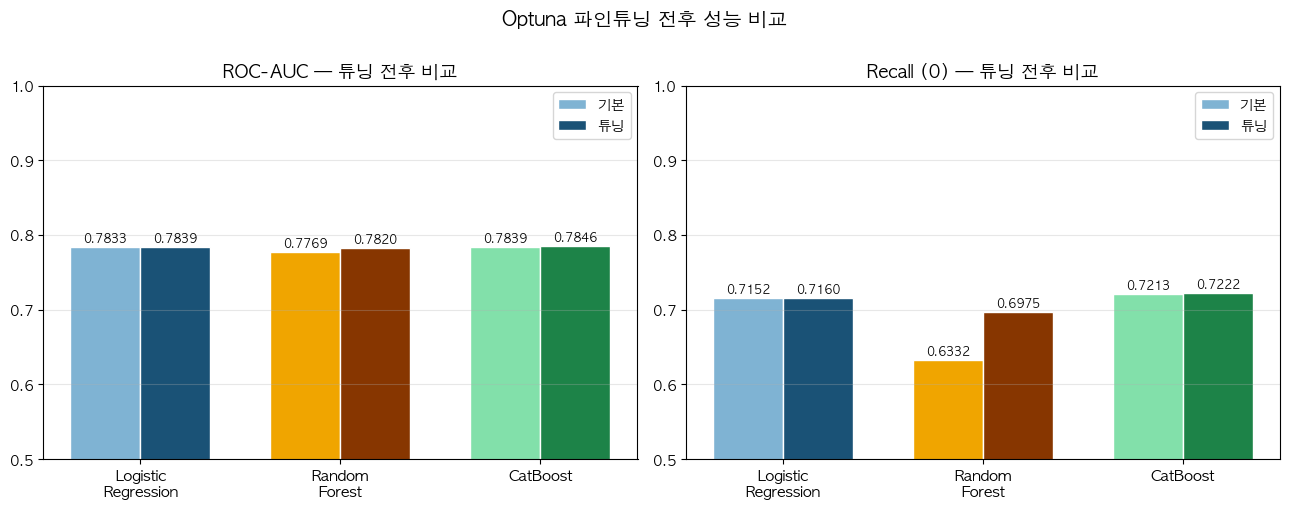

In [25]:
# ── 튜닝 전후 ROC-AUC / Recall(0) 비교 막대 그래프 ───────────────────────
model_labels = ["Logistic\nRegression", "Random\nForest", "CatBoost"]
x = np.arange(len(model_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette_before = ["#7FB3D3", "#F0A500", "#82E0AA"]
palette_after  = ["#1A5276", "#873600", "#1D8348"]

for ax, metric in zip(axes, ["ROC-AUC", "Recall (0)"]):
    vals_before = [list(before.values())[i][metric] for i in range(3)]
    vals_after  = [list(after.values())[i][metric]  for i in range(3)]

    bars1 = ax.bar(x - width/2, vals_before, width, label="기본",  color=palette_before, edgecolor="white")
    bars2 = ax.bar(x + width/2, vals_after,  width, label="튜닝",  color=palette_after,  edgecolor="white")

    ax.set_title(f"{metric} — 튜닝 전후 비교", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=11)
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8.5)

plt.suptitle("Optuna 파인튜닝 전후 성능 비교", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

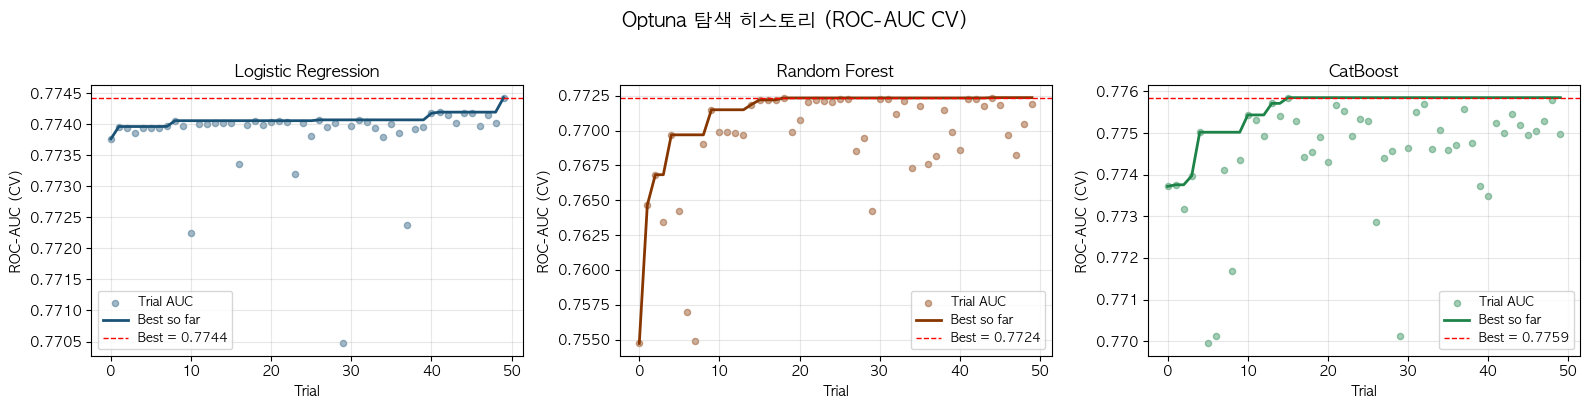

In [26]:
# ── Optuna 최적화 히스토리 (각 모델 trial별 best value 추이) ──────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (study, name, color) in zip(axes, [
    (lr_study,  "Logistic Regression", "#1A5276"),
    (rf_study,  "Random Forest",       "#873600"),
    (cat_study, "CatBoost",            "#1D8348"),
]):
    values     = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(values)

    ax.scatter(range(len(values)), values, alpha=0.4, s=20, color=color, label="Trial AUC")
    ax.plot(range(len(best_so_far)), best_so_far, color=color, linewidth=2, label="Best so far")
    ax.axhline(max(best_so_far), color="red", linestyle="--", linewidth=1,
               label=f"Best = {max(best_so_far):.4f}")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Trial")
    ax.set_ylabel("ROC-AUC (CV)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Optuna 탐색 히스토리 (ROC-AUC CV)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [27]:
# ── 최적 파라미터 최종 정리 ──────────────────────────────────────────────
sep = "─" * 60
print(sep)
print("  Logistic Regression — 최적 파라미터")
print(sep)
for k, v in lr_study.best_params.items():
    print(f"  {k:<25}: {v}")
print(f"  {'Best CV ROC-AUC':<25}: {lr_study.best_value:.4f}")

print()
print(sep)
print("  Random Forest — 최적 파라미터")
print(sep)
for k, v in rf_study.best_params.items():
    print(f"  {k:<25}: {v}")
print(f"  {'Best CV ROC-AUC':<25}: {rf_study.best_value:.4f}")

print()
print(sep)
print("  CatBoost — 최적 파라미터")
print(sep)
for k, v in cat_study.best_params.items():
    print(f"  {k:<25}: {v}")
print(f"  {'Best CV ROC-AUC':<25}: {cat_study.best_value:.4f}")
print(sep)

────────────────────────────────────────────────────────────
  Logistic Regression — 최적 파라미터
────────────────────────────────────────────────────────────
  solver                   : saga
  penalty                  : l1
  C                        : 0.08775811312684415
  Best CV ROC-AUC          : 0.7744

────────────────────────────────────────────────────────────
  Random Forest — 최적 파라미터
────────────────────────────────────────────────────────────
  n_estimators             : 300
  max_depth                : 10
  min_samples_split        : 14
  min_samples_leaf         : 8
  max_features             : sqrt
  Best CV ROC-AUC          : 0.7724

────────────────────────────────────────────────────────────
  CatBoost — 최적 파라미터
────────────────────────────────────────────────────────────
  iterations               : 1000
  learning_rate            : 0.018051353424731104
  depth                    : 7
  l2_leaf_reg              : 3.937323054801693
  bagging_temperature      : 0.49708539361